###Tratamento de dados a respeito de letras de música.
Time 07
- Luis Ernani M. C. Viniski
- Lucas Barbosa dos Santos



In [ ]:
!pip install python-Levenshtein


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from Levenshtein import distance as levenshtein_distance
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial.distance import jaccard, cosine
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
url = "https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2001/dados/dataset_lyrics.csv"
df = pd.read_csv(url)

In [ ]:
print("Preview do dataset:")
print(df.head())


Preview do dataset:
   cantorId     cantorNome               musicaNome  \
0         0  10000-maniacs           More Than This   
1         0  10000-maniacs        Because The Night   
2         0  10000-maniacs           These Are Days   
3         0  10000-maniacs          A Campfire Song   
4         0  10000-maniacs  Everyday Is Like Sunday   

                                               letra  
0  I could feel at the time. There was no way of ...  
1  Take me now, baby, here as I am. Hold me close...  
2  These are. These are days you'll remember. Nev...  
3  A lie to say, "O my mountain has coal veins an...  
4  Trudging slowly over wet sand. Back to the ben...  


In [ ]:
print("\nInformações do dataset:")
print(df.info())


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49387 entries, 0 to 49386
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cantorId    49387 non-null  int64 
 1   cantorNome  49387 non-null  object
 2   musicaNome  49387 non-null  object
 3   letra       49376 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB
None


##Limpeza da base de dados


In [ ]:
#Remover duplicados e valores nulos
df_clean = df.dropna().drop_duplicates()

In [ ]:
#conversão para strinf e padronização em minuscula
df_clean['letra'] = df_clean['letra'].astype(str).str.lower()
df_clean['letra_clean'] = df_clean['letra'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

In [ ]:
#tratar o titulo da música
if 'musicaNome' in df_clean.columns:
    df_clean['musicaNome'] = df_clean['musicaNome'].astype(str)

In [ ]:
#Quantidade de palavras em cada letra, criando nova coluna
df_clean['qtd_palavras'] = df_clean['letra'].apply(lambda x: len(x.split()))

##Criando gráfico para análise

Top 10 artistas com mais músicas

<ipython-input-11-4ca167926a37>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artistas.index, y=top_artistas.values, palette='rocket')


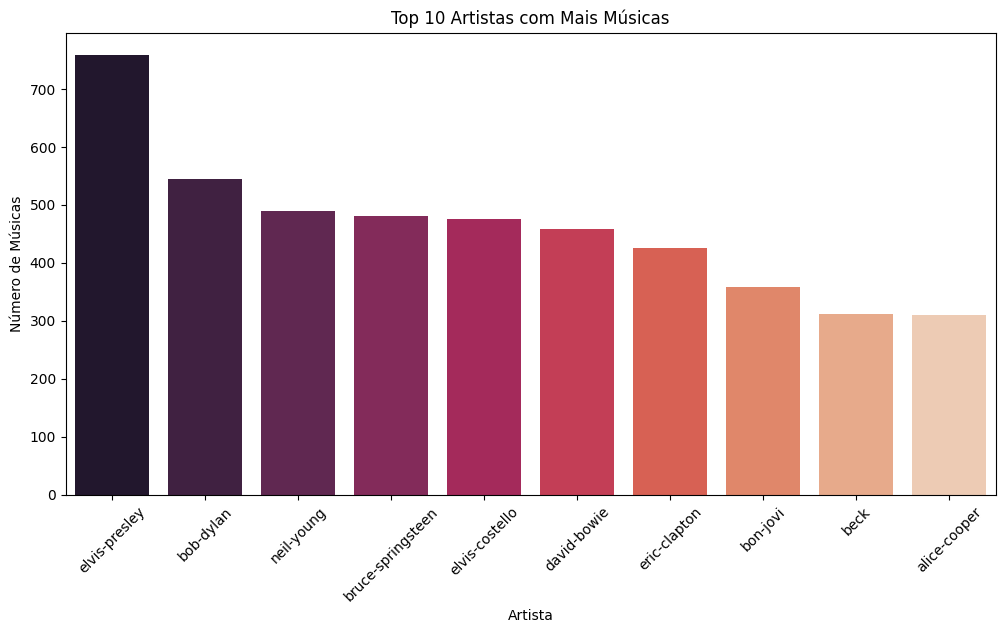

In [ ]:
plt.figure(figsize=(12,6))
top_artistas = df_clean['cantorNome'].value_counts().head(10)
sns.barplot(x=top_artistas.index, y=top_artistas.values, palette='rocket')
plt.title('Top 10 Artistas com Mais Músicas')
plt.xlabel('Artista')
plt.ylabel('Número de Músicas')
plt.xticks(rotation=45)
plt.show()


Músicas mais longas (TOP 20):
                                     musicaNome  qtd_palavras
cantorNome                                                   
ozzy-osbourne      Suicide Solution (tablatura)          2781
ozzy-osbourne      Bark At The Moon (tablatura)          2409
black-sabbath              War Pigs (tablatura)          2186
david-bowie               It's No Game (part 1)          1965
bush                                  Solutions          1744
led-zeppelin     Stairway To Heaven (tablatura)          1715
bob-dylan        Last Thoughts on Woody Guthrie          1705
metallica      Fight Fire With Fire (tablatura)          1490
david-bowie                 Neighborhood Threat          1414
green-day                Homecoming (tablatura)          1388


<ipython-input-12-8f66cc1e61e8>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_longas.head(10)["qtd_palavras"], y=df_longas.head(10)["musicaNome"], palette='Blues_r')


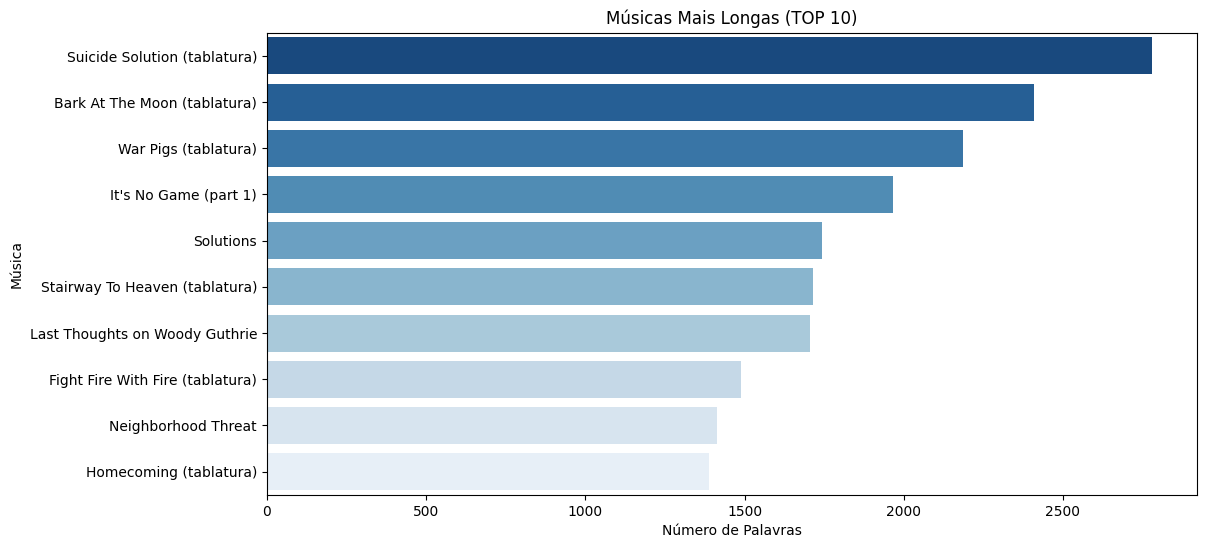

In [ ]:
df_longas = df_clean.sort_values(by="qtd_palavras", ascending=False)

# Exibir as 10 músicas com mais palavras
print("\nMúsicas mais longas (TOP 20):")
if 'musicaNome' in df_longas.columns:
    print(df_longas[['cantorNome', 'musicaNome', 'qtd_palavras']].head(10).set_index("cantorNome"))
else:
    print(df_longas[['cantorNome', 'qtd_palavras']].head(10).set_index("cantorNome"))

# Criar gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=df_longas.head(10)["qtd_palavras"], y=df_longas.head(10)["musicaNome"], palette='Blues_r')
plt.xlabel("Número de Palavras")
plt.ylabel("Música")
plt.title("Músicas Mais Longas (TOP 10)")
plt.show()

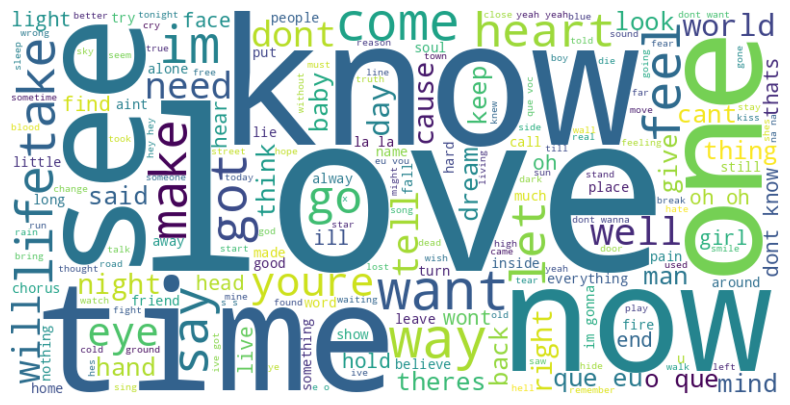

In [ ]:
#Nuvem de palavras com as palavras mais usadas nas músicas
text = " ".join(df_clean['letra_clean'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


Palavras únicas por artista (TOP 20):
                             palavras_unicas
cantorNome                                  
bob-dylan                               8666
elvis-costello                          7612
bruce-springsteen                       7097
david-bowie                             6887
nick-cave-the-bad-seeds                 6589
bad-religion                            5978
elvis-presley                           5917
beck                                    5904
beastie-boys                            5883
311                                     5704
alice-cooper                            5152
neil-young                              5068
alanis-morissette                       4820
lou-reed                                4769
manic-street-preachers                  4738
lulu-santos                             4710
marillion                               4708
charlie-brown-jr                        4647
aerosmith                               4578
ian-dury-and-the

<ipython-input-14-ddb1e0ad4c60>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_word_df.head(20)["palavras_unicas"], y=unique_word_df.head(20).index, palette='magma')


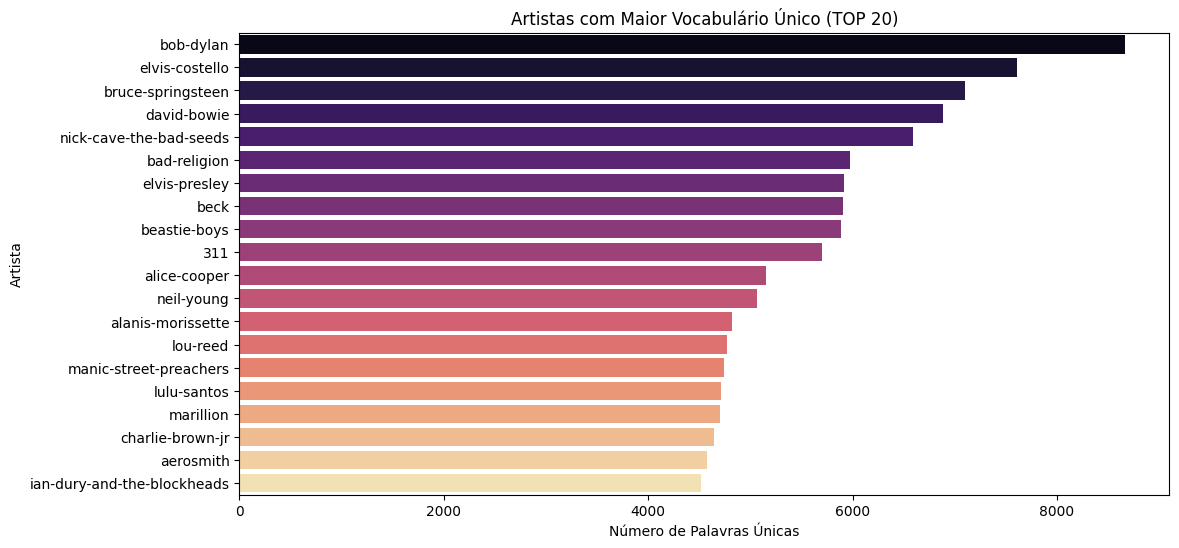

In [ ]:
#Palavras únicas nas músicas
unique_words_per_artist = {}

# Processar cada artista
for artist in df_clean["cantorNome"].unique():
    all_words = []

    # Coletar todas as palavras das músicas do artista
    artist_songs = df_clean[df_clean["cantorNome"] == artist]["letra_clean"]
    for lyrics in artist_songs:
        all_words.extend(lyrics.split())  # Como já está limpo, só precisamos dividir

    # Remover stopwords
    all_words = [word for word in all_words if word not in stop_words]

    # Identificar palavras únicas
    unique_words_per_artist[artist] = len(set(all_words))

# Transformar em DataFrame e ordenar do maior para o menor vocabulário único
unique_word_df = pd.DataFrame(unique_words_per_artist.items(), columns=["cantorNome", "palavras_unicas"])
unique_word_df = unique_word_df.sort_values(by="palavras_unicas", ascending=False).set_index("cantorNome")

# Exibir os 20 artistas com maior vocabulário único no formato desejado
print("\nPalavras únicas por artista (TOP 20):")
print(unique_word_df.head(20))

# Criar gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=unique_word_df.head(20)["palavras_unicas"], y=unique_word_df.head(20).index, palette='magma')
plt.xlabel("Número de Palavras Únicas")
plt.ylabel("Artista")
plt.title("Artistas com Maior Vocabulário Único (TOP 20)")
plt.show()

<ipython-input-15-796e13a6f567>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_term['ocorrencias'] = df_term['letra_clean'].apply(lambda x: x.split().count(term))
<ipython-input-15-796e13a6f567>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=artistas.values, y=artistas.index, palette='viridis')


Música(s) que mais repete o termo 'rain' (ocorrências: 26):
           cantorNome   musicaNome  ocorrencias
31971  jonas-brothers  Summer Rain           26

Ocorrências do termo 'rain' por artista (TOP20):
cantorNome
bruce-springsteen          108
bob-dylan                   88
eric-clapton                74
neil-young                  56
nick-cave-the-bad-seeds     54
elvis-presley               53
bon-jovi                    49
david-bowie                 42
marianne-faithfull          40
noel-gallagher              38
afi                         38
paul-mccartney              36
kiss                        36
jonas-brothers              35
coldplay                    35
p-o-d                       32
marillion                   32
oar                         31
iron-maiden                 31
counting-crows              30
Name: ocorrencias, dtype: int64


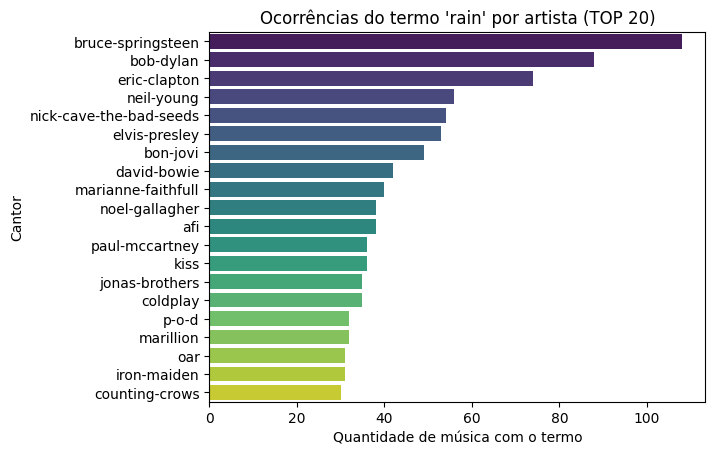

In [ ]:
def buscar_termo(term):
    term = term.lower()
    # Filtrar músicas que contêm o termo na versão limpa da letra
    df_term = df_clean[df_clean['letra_clean'].str.contains(term)]

    # Contar quantas vezes o termo aparece em cada música
    df_term['ocorrencias'] = df_term['letra_clean'].apply(lambda x: x.split().count(term))

    # Identificar a música com o maior número repetição
    max_occ = df_term['ocorrencias'].max()
    musica_max = df_term[df_term['ocorrencias'] == max_occ]

    print(f"Música(s) que mais repete o termo '{term}' (ocorrências: {max_occ}):")
    if 'musicaNome' in musica_max.columns:
        print(musica_max[['cantorNome', 'musicaNome', 'ocorrencias']])
    else:
        print(musica_max[['cantorNome', 'ocorrencias']])

    # Agregar as ocorrências por artista
    artistas = df_term.groupby('cantorNome')['ocorrencias'].sum().sort_values(ascending=False).head(20)
    print(f"\nOcorrências do termo '{term}' por artista (TOP20):")
    print(artistas)

    sns.barplot(x=artistas.values, y=artistas.index, palette='viridis')
    plt.rcParams['figure.figsize'] = (16, 10)
    plt.xlabel("Quantidade de música com o termo")
    plt.ylabel("Cantor")
    plt.title(f"Ocorrências do termo '{term}' por artista (TOP 20)")
    plt.show()

buscar_termo("rain")

In [ ]:
# Texto de busca (entrada do usuário)
texto_busca = "bohemian rhapsody"  # Altere para testar com diferentes buscas

# Certificar que os nomes das músicas estão em texto limpo
df_clean["musicaNome"] = df_clean["musicaNome"].astype(str).str.lower().apply(lambda x: re.sub(r'[^a-z\s]', '', x))

# Criar listas para armazenar as distâncias
resultados = []

for musica in df_clean["musicaNome"]:
    # Distância de Levenshtein
    dist_lev = levenshtein_distance(texto_busca, musica)

    # Distância de Jaccard
    set_texto = set(texto_busca.split())
    set_musica = set(musica.split())
    dist_jaccard = 1 - (len(set_texto & set_musica) / len(set_texto | set_musica))  # 1 - Jaccard Similarity

    # Armazenar os resultados
    resultados.append((musica, dist_lev, dist_jaccard))

# Transformar em DataFrame e ordenar por distância de Levenshtein (menor é melhor)
df_resultados = pd.DataFrame(resultados, columns=["musicaNome", "dist_levenshtein", "dist_jaccard"])
df_resultados = df_resultados.sort_values(by="dist_levenshtein").head(10)

# Exibir resultados
print("\n🔍 Músicas mais próximas do texto buscado:")
print(df_resultados.set_index("musicaNome"))

# Distância de Levenshtein → Mede quantas edições são necessárias para transformar um nome no outro. Quanto menor, melhor.
# Distância de Jaccard → Mede a interseção entre dois conjuntos em relação à sua união.Quanto menor a distância de Jaccard, mais similares os textos são.


🔍 Músicas mais próximas do texto buscado:
                    dist_levenshtein  dist_jaccard
musicaNome                                        
bohemian rhapsody                  0      0.000000
bohemian rhapsody                  0      0.000000
brohemian rhapsody                 1      0.666667
boomin granny                      9      1.000000
hole in the sky                    9      1.000000
human hands                        9      1.000000
ocean rain                        10      1.000000
love is easy                      10      1.000000
shakin hands                      10      1.000000
love in song                      10      1.000000


In [ ]:
df_resultados = pd.DataFrame(resultados, columns=["musicaNome", "dist_levenshtein", "dist_jaccard"])
df_resultados = df_resultados.sort_values(by="dist_levenshtein").head(10)

<ipython-input-18-36da86e42c31>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="dist_levenshtein", y="musicaNome", data=df_resultados, palette="mako")


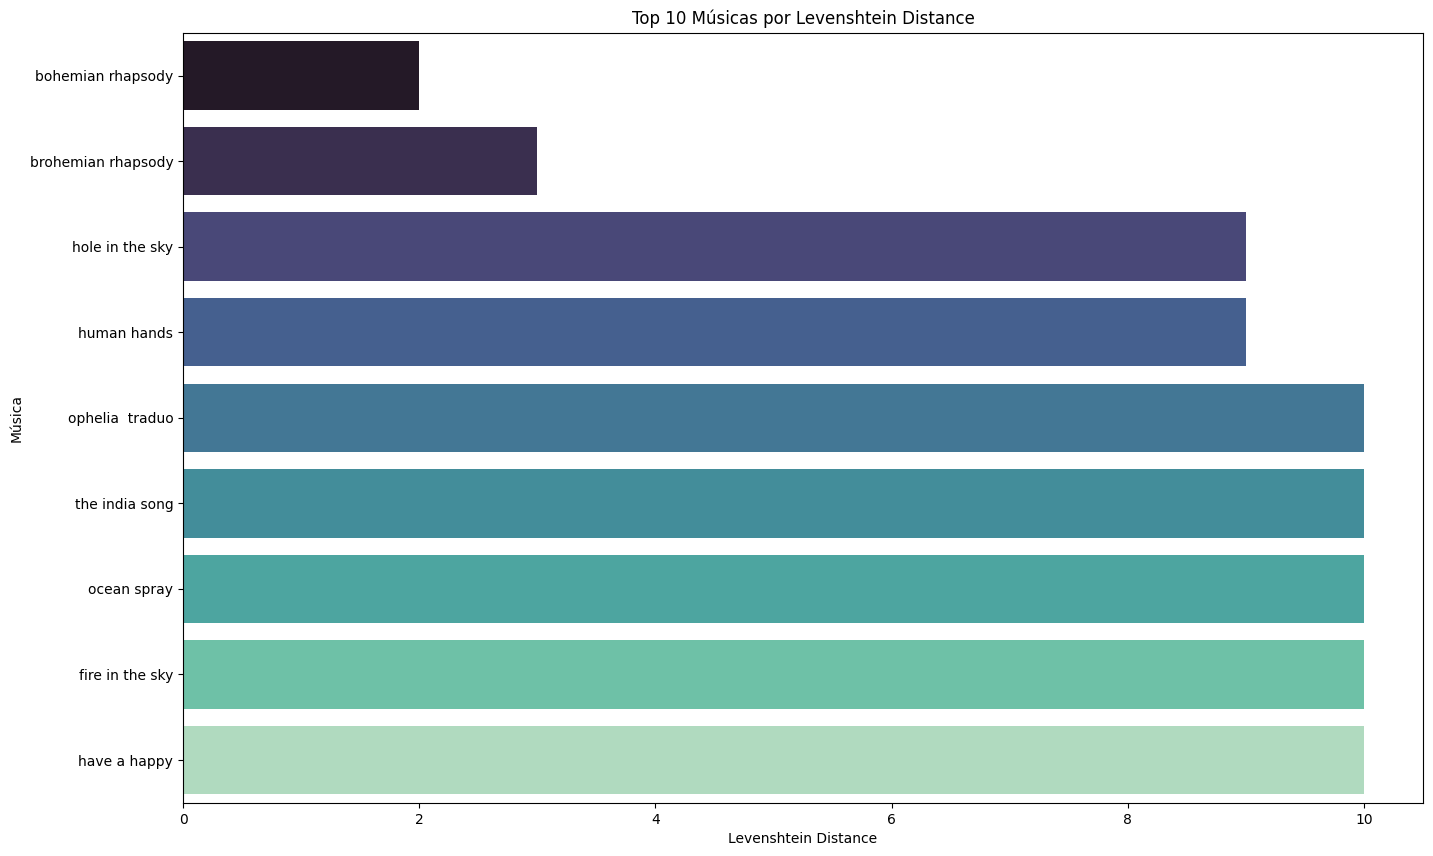

In [ ]:
plt.figure(figsize=(16, 10))
sns.barplot(x="dist_levenshtein", y="musicaNome", data=df_resultados, palette="mako")
plt.xlabel("Levenshtein Distance")
plt.ylabel("Música")
plt.title("Top 10 Músicas por Levenshtein Distance")
plt.show()

<ipython-input-19-ba053cde7752>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="dist_jaccard", y="musicaNome", data=df_resultados, palette="rocket")


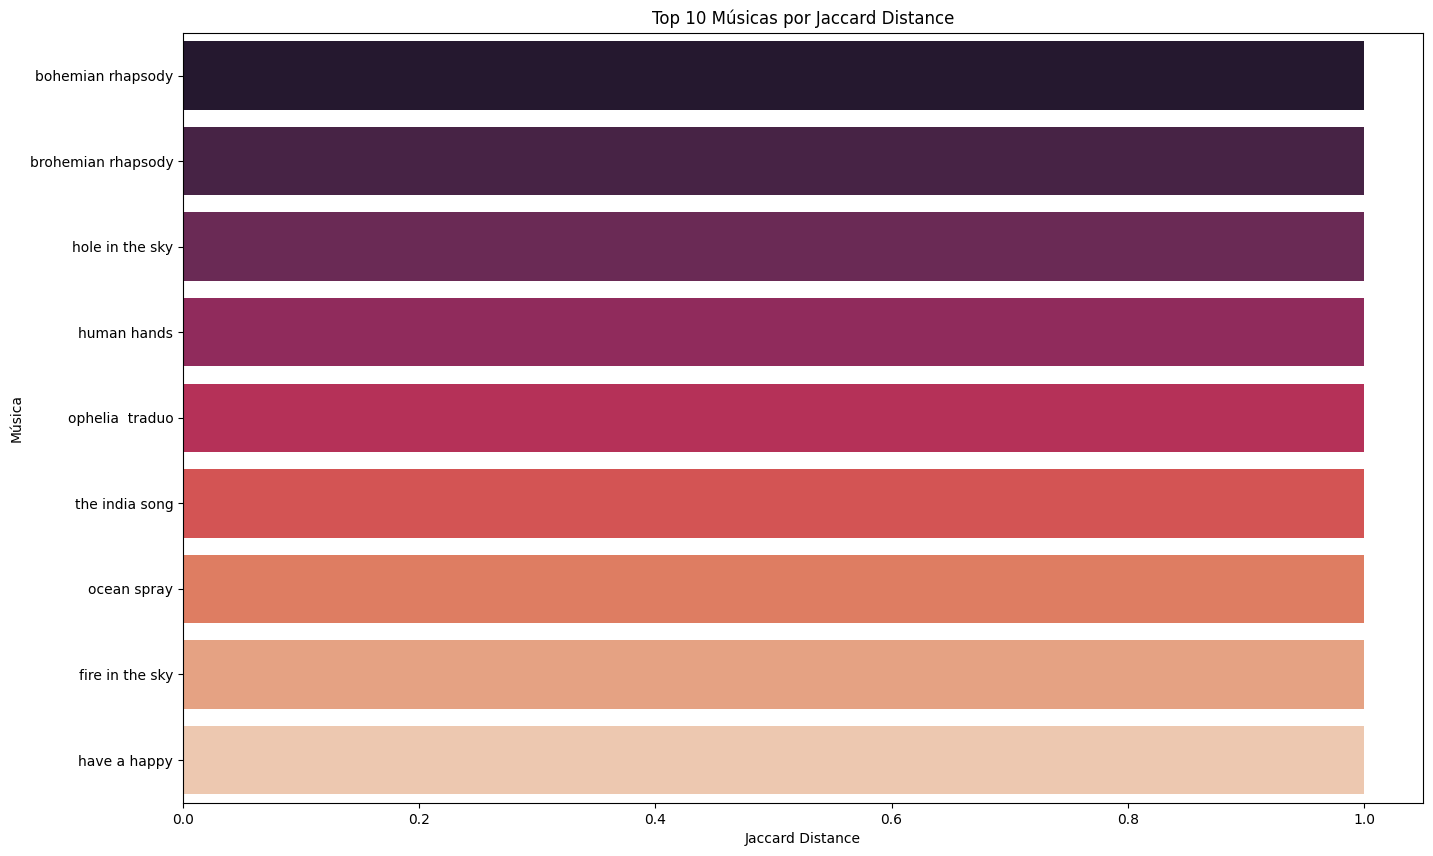

In [ ]:
plt.figure(figsize=(16, 10))
sns.barplot(x="dist_jaccard", y="musicaNome", data=df_resultados, palette="rocket")
plt.xlabel("Jaccard Distance")
plt.ylabel("Música")
plt.title("Top 10 Músicas por Jaccard Distance")
plt.show()